# Practical Session 01b &mdash; Unstructured data: images, sound, time series

**Companion to Lecture&nbsp;01.** Notebook **01a** showed structured (tabular) data, where one
example is a **row**. But most of the world's data is not a neat table: photos, audio,
sensor streams, text. This notebook shows how each of these becomes **numbers in an array** &mdash;
and why their *shape* carries meaning that a table's column order does not.

> ⭐ **Key idea.** Everything a model sees is an array of numbers. What changes between
> modalities is the **shape** and what the **axes mean**:
> * a grayscale image is a 2-D matrix $H\times W$ (a grid of pixel intensities),
> * a color image is a 3-D tensor $H\times W\times 3$ (three stacked color channels),
> * a sound is a 1-D signal (amplitude sampled over time),
> * a time series is a 1-D sequence indexed by time (**order matters**).
>
> The train / validation / test logic from the lecture is *identical*; only the data and the
> model change.

*Run each cell (Shift+Enter). This notebook is self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from nb_utils import use_style

use_style("notes")
print("ready")

ready


## Part A &mdash; Images

### A.1 A grayscale image *is* a matrix

An image is a grid of **pixels**; each pixel is a number (its brightness). So a grayscale
image is literally a 2-D array of shape $H\times W$ (height &times; width). We use one of the
8&times;8 handwritten digits bundled with scikit-learn.

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
img = digits.images[0]          # one 8x8 grayscale image
print("shape:", img.shape, "| dtype:", img.dtype, "| value range:", img.min(), "to", img.max())
print("\nThe image as a matrix of numbers (higher = brighter):")
print(img.astype(int))

shape: (8, 8) | dtype: float64 | value range: 0.0 to 15.0

The image as a matrix of numbers (higher = brighter):
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]


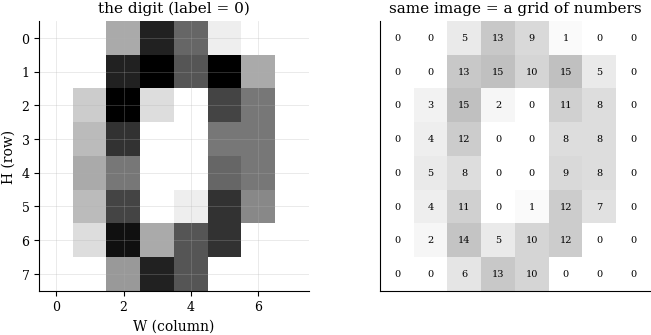

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.0, 3.4))
a1.imshow(img, cmap="gray_r")
a1.set_title(f"the digit (label = {digits.target[0]})"); a1.set_xlabel("W (column)"); a1.set_ylabel("H (row)")
# annotate the pixel values on top of the image
for i in range(8):
    for j in range(8):
        a2.text(j, i, int(img[i, j]), ha="center", va="center", fontsize=7)
a2.imshow(img, cmap="gray_r", alpha=0.25); a2.set_title("same image = a grid of numbers")
a2.set_xticks([]); a2.set_yticks([])
plt.show()

> 🔬 **Going deeper.** Pixel **intensity ranges** depend on the format: these digits use
> `0..16`; a typical photo uses `0..255` (8-bit `uint8`) or `0.0..1.0` (float). The **row**
> index is the vertical position ($H$) and the **column** index is the horizontal position
> ($W$) &mdash; and unlike a spreadsheet, *which* row/column a value sits in is meaningful:
> neighboring pixels belong together.

### A.2 A color image is a 3-D tensor (stacked channels)

A color image adds a third axis: **color channels**. An RGB image has shape
$H\times W\times 3$ &mdash; three grayscale matrices (Red, Green, Blue) stacked. We use a real
photo bundled with matplotlib (no download).

In [4]:
photo = plt.imread(cbook.get_sample_data("grace_hopper.jpg"))   # bundled sample photo
print("shape:", photo.shape, "  <- (H, W, 3): height, width, 3 color channels")
print("dtype:", photo.dtype, "| value range:", photo.min(), "to", photo.max())
print("one pixel (top-left) as an (R, G, B) triple:", photo[0, 0])

shape: (600, 512, 3)   <- (H, W, 3): height, width, 3 color channels
dtype: uint8 | value range: 0 to 255
one pixel (top-left) as an (R, G, B) triple: [21 24 77]


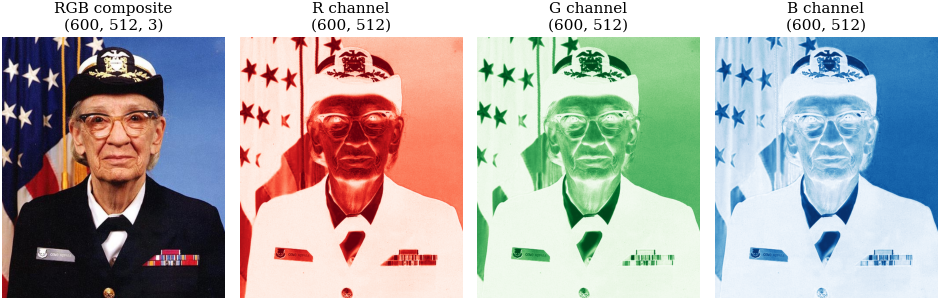

In [6]:
r, g, b = photo[:, :, 0], photo[:, :, 1], photo[:, :, 2]
fig, ax = plt.subplots(1, 4, figsize=(9.5, 3.0))
ax[0].imshow(photo);              ax[0].set_title(f"RGB composite\n{photo.shape}")
ax[1].imshow(r, cmap="Reds", vmin=0, vmax=255);     ax[1].set_title(f"R channel\n{r.shape}")
ax[2].imshow(g, cmap="Greens", vmin=0, vmax=255);   ax[2].set_title(f"G channel\n{g.shape}")
ax[3].imshow(b, cmap="Blues", vmin=0, vmax=255);    ax[3].set_title(f"B channel\n{b.shape}")
for a in ax: a.axis("off")
plt.show()

Each channel is a full $H\times W$ matrix; the color you see is what happens when the three
are combined. Editing a channel edits the image &mdash; concrete proof that the picture is *just
numbers*:

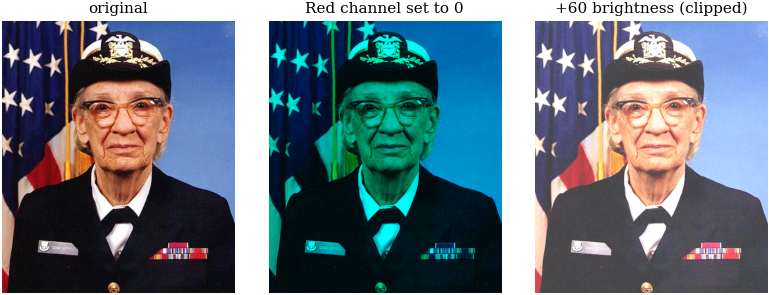

In [7]:
no_red = photo.copy()
no_red[:, :, 0] = 0                 # zero out the Red channel
brighter = np.clip(photo.astype(int) + 60, 0, 255).astype(np.uint8)  # arithmetic on pixels

fig, ax = plt.subplots(1, 3, figsize=(8.0, 3.0))
ax[0].imshow(photo);    ax[0].set_title("original")
ax[1].imshow(no_red);   ax[1].set_title("Red channel set to 0")
ax[2].imshow(brighter); ax[2].set_title("+60 brightness (clipped)")
for a in ax: a.axis("off")
plt.show()

### A.3 From image to feature vector &mdash; and what is lost

A simple classifier (like the one in `session-01-demos.ipynb`) treats an image as a plain
vector by **flattening** the matrix into one long row. That works, but it silently discards
the 2-D layout: pixels that were neighbors are scattered apart.

In [8]:
flat = img.reshape(-1)          # 8x8 -> length-64 vector
print("image", img.shape, "-> flattened vector", flat.shape)
print("first 16 values:", flat[:16].astype(int))

# The whole digits dataset, flattened, is a design matrix X just like in 01a:
X_digits = digits.images.reshape(len(digits.images), -1)
print("\nWhole dataset as a design matrix X:", X_digits.shape, " (n images, 64 pixel-features)")
print("targets y:", digits.target.shape, "-> the digit 0..9 each image shows")

image (8, 8) -> flattened vector (64,)
first 16 values: [ 0  0  5 13  9  1  0  0  0  0 13 15 10 15  5  0]

Whole dataset as a design matrix X: (1797, 64)  (n images, 64 pixel-features)
targets y: (1797,) -> the digit 0..9 each image shows


> ⚠️ **Watch out.** Flattening makes the array a table, but "pixel 7" and "pixel 15" are no
> longer known to be vertically adjacent. For images this thrown-away structure matters a
> lot &mdash; it is exactly why **convolutional networks** (a later session), which keep the 2-D
> grid, dominate computer vision. The lesson: *the representation you choose decides which
> models make sense.*

> 💡 **Optional (your own image).** To load a real image from disk or a URL, use
> `PIL.Image.open(...)` or `imageio.imread("https://.../photo.jpg")` and then
> `np.asarray(...)` &mdash; you get the same $H\times W\times 3$ tensor. (Needs the file / internet.)

## Part B &mdash; Sound

### B.1 A sound is a 1-D signal sampled over time

Audio is air pressure over time. A microphone measures it at a fixed **sampling rate**
`sr` (samples per second, Hz), giving a 1-D array of length `sr &times; duration`. We *synthesize*
a pure 440&nbsp;Hz tone (musical note A) so nothing needs to be downloaded.

sampling rate: 16000 Hz | duration: 1.0 s
signal shape: (16000,)  (= sr * duration = 16000 samples)


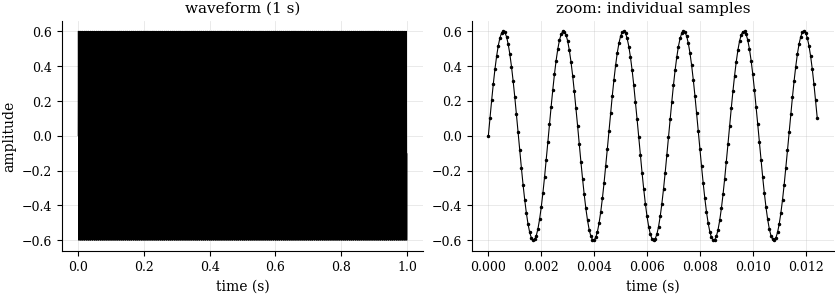

In [9]:
sr = 16000                     # sampling rate: 16 000 samples per second
dur = 1.0                      # seconds
t = np.linspace(0, dur, int(sr * dur), endpoint=False)
tone = 0.6 * np.sin(2 * np.pi * 440 * t)     # a 440 Hz sine wave

print("sampling rate:", sr, "Hz | duration:", dur, "s")
print("signal shape:", tone.shape, " (= sr * duration =", int(sr*dur), "samples)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.0))
a1.plot(t, tone, lw=0.6); a1.set_title("waveform (1 s)"); a1.set_xlabel("time (s)"); a1.set_ylabel("amplitude")
a2.plot(t[:200], tone[:200], marker=".", ms=3, lw=0.8)
a2.set_title("zoom: individual samples"); a2.set_xlabel("time (s)")
plt.show()

In [10]:
# In Jupyter you can actually LISTEN (embeds a small player; safe to skip if it doesn't render):
try:
    from IPython.display import Audio, display
    display(Audio(tone, rate=sr))
except Exception as e:
    print("audio widget unavailable in this environment:", e)

### B.2 Frequency content: the FFT

The *pitch* of a sound lives in its **frequencies**. The Fast Fourier Transform (FFT)
decomposes the signal into the frequencies it contains. A pure tone shows a single spike;
a **chord** (several tones added) shows several.

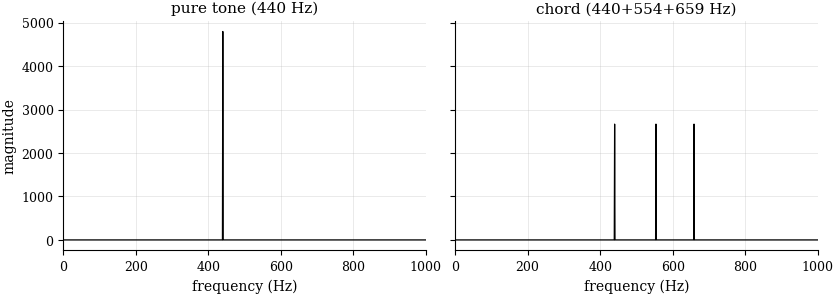

In [11]:
chord = (np.sin(2*np.pi*440*t) + np.sin(2*np.pi*554*t) + np.sin(2*np.pi*659*t)) / 3  # A major triad

def spectrum(sig, sr):
    mag = np.abs(np.fft.rfft(sig))
    freq = np.fft.rfftfreq(len(sig), 1/sr)
    return freq, mag

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.0), sharey=True)
for ax, sig, name in [(a1, tone, "pure tone (440 Hz)"), (a2, chord, "chord (440+554+659 Hz)")]:
    f, m = spectrum(sig, sr)
    ax.plot(f, m, lw=0.9); ax.set_xlim(0, 1000); ax.set_title(name); ax.set_xlabel("frequency (Hz)")
a1.set_ylabel("magnitude")
plt.show()

### B.3 A spectrogram turns sound into an image

Real sounds change over time, so we compute the spectrum in short overlapping windows and
stack them: a **spectrogram**, a 2-D *time&times;frequency* matrix. Sound becomes an image &mdash;
which is exactly how many audio models "see" it. Here is a **chirp** whose pitch rises with
time (a clean diagonal).

spectrogram matrix shape (freq bins, time frames): (257, 122)


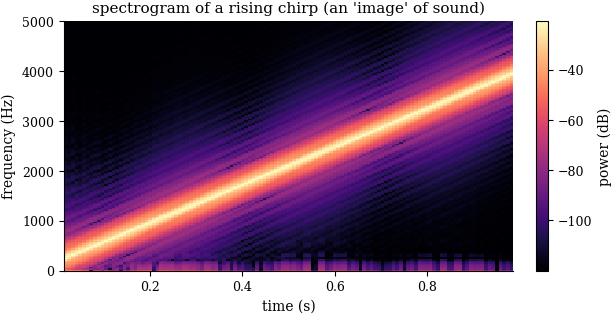

In [12]:
from scipy import signal as sps
chirp = sps.chirp(t, f0=200, f1=4000, t1=dur, method="linear")   # frequency sweeps 200 -> 4000 Hz
f, tt, Sxx = sps.spectrogram(chirp, sr, nperseg=512, noverlap=384)
print("spectrogram matrix shape (freq bins, time frames):", Sxx.shape)

fig, ax = plt.subplots(figsize=(6.2, 3.2))
m = ax.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-12), shading="auto", cmap="magma")
ax.set_ylim(0, 5000); ax.set_ylabel("frequency (Hz)"); ax.set_xlabel("time (s)")
ax.set_title("spectrogram of a rising chirp (an 'image' of sound)")
fig.colorbar(m, ax=ax, label="power (dB)")
plt.show()

> 🔬 **Going deeper.** Raw audio is a long 1-D array (16&nbsp;000 numbers *per second*), often
> too long and too raw to model directly. Classic audio ML first extracts **features** &mdash; a
> spectrogram, or MFCCs &mdash; converting the signal into a compact 2-D representation, then
> treats it much like an image. You can also read/write real audio with
> `scipy.io.wavfile.write("tone.wav", sr, (tone*32767).astype(np.int16))`.

## Part C &mdash; Time series

### C.1 A sequence where order is everything

A time series is a value measured repeatedly over time: temperature, sales, a heartbeat. Its
defining property is that the **order matters** &mdash; you cannot shuffle the rows. We synthesize
6 years of monthly data as **trend + seasonality + noise**, a classic decomposition.

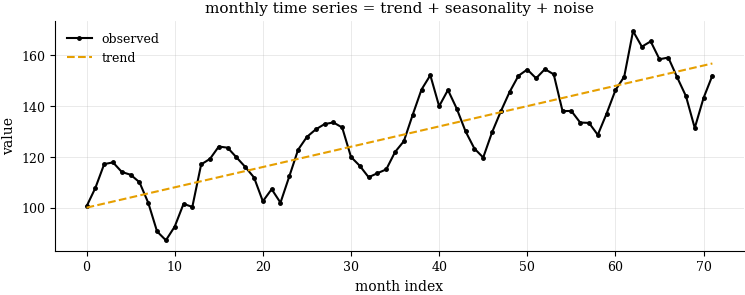

In [13]:
rng = np.random.default_rng(0)
months = np.arange(72)                         # 6 years, monthly
trend = 100 + 0.8 * months                     # slow upward drift
seasonal = 15 * np.sin(2 * np.pi * months / 12)  # yearly cycle (period 12)
noise = rng.normal(0, 4, size=months.size)
series = trend + seasonal + noise

fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.plot(months, series, marker=".", label="observed")
ax.plot(months, trend, "--", label="trend")
ax.set_xlabel("month index"); ax.set_ylabel("value"); ax.set_title("monthly time series = trend + seasonality + noise")
ax.legend()
plt.show()

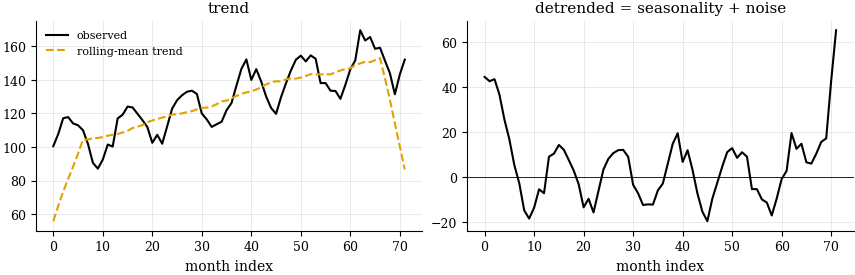

In [14]:
# A quick, library-free decomposition: rolling mean = trend, remainder = seasonal + noise
s = np.asarray(series, float)
k = 12
trend_est = np.convolve(s, np.ones(k)/k, mode="same")   # 12-month moving average
detrended = s - trend_est

fig, ax = plt.subplots(1, 2, figsize=(8.6, 2.8))
ax[0].plot(months, s, label="observed"); ax[0].plot(months, trend_est, "--", label="rolling-mean trend")
ax[0].set_title("trend"); ax[0].legend(fontsize=8)
ax[1].plot(months, detrended); ax[1].set_title("detrended = seasonality + noise"); ax[1].axhline(0, color="k", lw=0.6)
for a in ax: a.set_xlabel("month index")
plt.show()

### C.2 The ML move: **windowing** turns a sequence into $(\mathbf{X}, \mathbf{y})$

To *forecast* with a supervised model, we reframe the sequence as a table: use the last `k`
values to predict the next one. A **sliding window** of width `k` builds the design matrix.
This is how sequences reconnect with the design-matrix idea from 01a.

In [15]:
def make_windows(seq, k):
    seq = np.asarray(seq, float)
    X = np.stack([seq[i:i+k] for i in range(len(seq)-k)])   # each row = k past values
    y = seq[k:]                                             # the next value
    return X, y

K = 12                       # <-- CHANGE ME: use the past K months to predict the next
Xw, yw = make_windows(series, K)
print("windowed design matrix X:", Xw.shape, " (rows = examples, cols = the last", K, "values)")
print("target y:", yw.shape, " (the value one step ahead)")
print("\nfirst window  ->", np.round(Xw[0], 1))
print("its target    ->", round(float(yw[0]), 1))

windowed design matrix X: (60, 12)  (rows = examples, cols = the last 12 values)
target y: (60,)  (the value one step ahead)

first window  -> [100.5 107.8 117.2 117.8 114.  112.9 110.  101.9  90.6  87.1  92.5 101.5]
its target    -> 100.3


### C.3 Split in **time order** &mdash; the test set is the future

You must never shuffle a time series before splitting: the test set has to be *later* than
the training set, or the model would peek at the future (leakage). Split by a cutoff date.

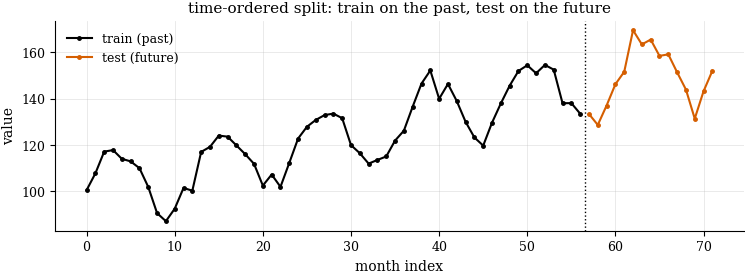

In [16]:
cut = int(0.8 * len(series))
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.plot(months[:cut], series[:cut], marker=".", label="train (past)")
ax.plot(months[cut:], series[cut:], marker=".", color="#D55E00", label="test (future)")
ax.axvline(cut - 0.5, color="k", ls=":", lw=1)
ax.set_xlabel("month index"); ax.set_ylabel("value")
ax.set_title("time-ordered split: train on the past, test on the future")
ax.legend()
plt.show()

> ⚠️ **Watch out.** `train_test_split(..., shuffle=True)` &mdash; the default &mdash; is **wrong** for a
> time series: it scatters future points into the training set. Use a time cutoff (as above)
> or scikit-learn's `TimeSeriesSplit`. Respecting causality is the time-series version of the
> "no leakage" rule.

## Part D &mdash; Text (a quick look)

Text is a sequence of words. The simplest way to turn a document into numbers is a
**bag-of-words**: count how often each vocabulary word appears. A collection of documents then
becomes a *documents &times; vocabulary* matrix &mdash; a design matrix again.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are friends",
]
vec = CountVectorizer()
counts = vec.fit_transform(corpus)          # sparse documents x vocabulary matrix
import pandas as pd
bow = pd.DataFrame(counts.toarray(), columns=vec.get_feature_names_out(),
                   index=[f"doc {i}" for i in range(len(corpus))])
print("bag-of-words matrix (rows = documents, columns = words):")
bow

bag-of-words matrix (rows = documents, columns = words):


,and,are,cat,cats,dog,dogs,friends,log,mat,on,sat,the
doc 0,0,0,1,0,0,0,0,0,1,1,1,2
doc 1,0,0,0,0,1,0,0,1,0,1,1,2
doc 2,1,1,0,1,0,1,1,0,0,0,0,0


> 🔬 **Going deeper.** Bag-of-words throws away **word order** (`"dog bites man"` and
> `"man bites dog"` get the same vector) &mdash; the text analogue of flattening an image. Modern
> NLP fixes this with **embeddings** and **transformers** (much later), which keep sequence
> information. Same recurring lesson: the representation defines what the model can learn.

## Recap & exercises

**Recap.** Every modality becomes an array; the shape and the meaning of the axes differ:

| modality | array shape | axes mean | note |
|---|---|---|---|
| grayscale image | $H\times W$ | rows, columns of pixels | spatial layout matters |
| color image | $H\times W\times 3$ | pixels + color channels | a stack of 3 matrices |
| sound | $(sr\cdot T,)$ | amplitude over time | spectrogram &rarr; 2-D image |
| time series | $(T,)$ | value over time | **order matters**; window it |
| text | documents &times; vocabulary | word counts | order lost in bag-of-words |

Flattening / bag-of-words makes any of these into a table, but **discards structure** &mdash;
which is why specialized models (CNNs, RNNs/transformers) exist in later sessions.

**Exercises.**
1. Display digit `digits.images[42]` as a matrix and an image; what is its label?
2. Convert the color photo to grayscale with the luminosity formula
   `0.299 R + 0.587 G + 0.114 B`; show it and give its new shape.
3. Change the tone frequency to 220 Hz and 880 Hz. Where does the FFT spike move, and how
   does the sound change (if you can play it)?
4. In `make_windows`, try `K = 3` and `K = 24`. How do `Xw.shape` and the forecasting task
   change? Which uses more history?
5. Add the sentence `"the cat and the dog"` to the corpus and re-fit the vectorizer. Which
   counts change, and does the vocabulary grow?

*Next:* **01c &mdash; exploratory data analysis & cleaning**: turning a messy real-world table into
something a model can trust.